# Data-Driven Control: DMDc and Koopman Lifted-Linear Models Driving Linear MPC on a Nonlinear Plant

**Abstract.** A linear Model Predictive Controller (MPC) is convex, fast, and
well understood — but real plants are nonlinear. This notebook shows how to
learn a *linear* surrogate of a nonlinear plant directly from data and control
the true plant with it. We identify two surrogates of a forced Van der Pol
oscillator: **DMDc** (Dynamic Mode Decomposition with control), a best-fit
linear model in the physical state, and a **Koopman eDMDc** model, a linear
model in a *lifted* coordinate space. We show the Koopman model predicts the
nonlinear response far more accurately (≈12× lower one-step error), then build
a linear MPC on each and stabilise the true nonlinear plant. The payoff: with a
realistically limited actuator the DMDc-MPC **fails** — it leaves a residual
limit cycle — while the Koopman-MPC drives the plant to rest.

**What you will be able to do:** collect persistently-exciting snapshots; fit
`dmdc` and `edmd`; wrap the fitted operators as simulatable Jaxonomy blocks
(`DMDForecaster`, `KoopmanPredictor`); build a `LinearDiscreteTimeMPC` on a
data-driven model; and diagnose why a linear-in-lifted-space model succeeds
where a linear-in-state model fails.

*Estimated reading time: 30–40 min. Runtime on CPU: ≈60–90 s (all cells run
live; no precomputed assets).*

**Prerequisites.** Basic state-space control and MPC; familiarity with
`jaxonomy.simulate` and `DiagramBuilder`. New framework concepts (`ode_block`,
`FeedthroughBlock`, `LeafSystem`) are introduced on first use.

---


## 1. The problem: control a plant whose origin is unstable

Our artifact is a **forced Van der Pol oscillator** — a canonical nonlinear
system that models everything from vacuum-tube circuits to cardiac rhythms and
vocal-fold oscillation. In state form, with position $x_1$, velocity $x_2$, and
a scalar control $u$ (a force on the velocity):

$$
\dot{x}_1 = x_2, \qquad
\dot{x}_2 = \mu\,(1 - x_1^2)\,x_2 - x_1 + u.
\tag{1}
$$

The term $\mu(1-x_1^2)x_2$ is *negative* damping near the origin ($|x_1|<1$) and
*positive* damping far out ($|x_1|>1$). The consequence is dramatic: **the
origin is an unstable equilibrium**, and every trajectory spirals out (or in) to
a **stable limit cycle**. Our control goal is to hold the plant at the origin —
we must actively fight the negative damping that pushes the state onto the limit
cycle.

Why not just linearise (1) about the origin and run a textbook linear MPC?
Because we want a *data-driven* workflow: no model, only measured snapshots
$(x_k, x_{k+1}, u_k)$. And we want the controller to be a linear MPC — a convex
quadratic program we can solve in microseconds — even though the plant is
nonlinear. The question this notebook answers is: **which linear surrogate, fit
from data, yields a linear MPC that actually works on the true nonlinear
plant?**

> **Note.** We use $\mu = 3$, a strongly nonlinear ("relaxation oscillation")
> regime, precisely because it is where a naive linear fit breaks down most
> visibly. A gentler $\mu$ makes the linear DMDc surrogate look deceptively good.


## 2. Two linear surrogates from data

We introduce the three algorithms before touching code.

### Symbols

| Symbol | Meaning | Units / shape |
|---|---|---|
| $\mathbf{x} = (x_1, x_2)$ | physical state (position, velocity) | — |
| $u$ | scalar control input | — |
| $\mu$ | Van der Pol nonlinearity strength | — (dimensionless) |
| $\Delta t$ | snapshot / control sampling period | s |
| $\mathbf{X}, \mathbf{X}'$ | snapshot pair $\mathbf{x}_k$, $\mathbf{x}_{k+1}$ | $2 \times m$ |
| $\mathbf{U}$ | input snapshots $u_k$ | $1 \times m$ |
| $\mathbf{A}, \mathbf{B}$ | DMDc discrete operators | $2\times2$, $2\times1$ |
| $\mathbf{g}(\mathbf{x})$ | dictionary of observables (lift) | $\mathbb{R}^2 \to \mathbb{R}^L$ |
| $\mathbf{K}, \mathbf{B}_z$ | Koopman operators on lifted state | $L\times L$, $L\times1$ |
| $\mathbf{C}$ | de-lift map (lifted $\to$ physical) | $2\times L$ |

### DMDc — a linear model in the physical state

DMDc (Proctor, Brunton & Kutz 2016) seeks the best-fit **discrete linear
model** of the sampled dynamics,

$$
\mathbf{x}_{k+1} \approx \mathbf{A}\,\mathbf{x}_k + \mathbf{B}\,u_k,
\tag{2}
$$

by stacking $\boldsymbol{\Omega} = [\mathbf{X};\,\mathbf{U}]$ and solving the
least-squares problem $[\mathbf{A}\;\mathbf{B}] = \mathbf{X}'\,\boldsymbol{\Omega}^{+}$.
It is the data-driven analogue of linearising the plant — and it inherits the
weakness of a *single* global linear model.

### Koopman eDMDc — a linear model in a lifted space

The Koopman operator advances *observables* $\mathbf{g}(\mathbf{x})$ of a
nonlinear system **linearly**. Extended DMD (Williams, Kevrekidis & Rowley 2015)
approximates it: lift each snapshot through a dictionary $\mathbf{g}$ and fit

$$
\mathbf{z}_{k+1} \approx \mathbf{K}\,\mathbf{z}_k + \mathbf{B}_z\,u_k,
\qquad \mathbf{z}_k = \mathbf{g}(\mathbf{x}_k),
\qquad \mathbf{x}_k \approx \mathbf{C}\,\mathbf{z}_k.
\tag{3}
$$

The dictionary places the identity observables first ($\mathbf{g}(\mathbf{x}) =
[x_1, x_2, 1, x_1^2, x_1 x_2, \dots]$), so the physical state is a linear read-out
$\mathbf{C}$ of the lifted state. Model (3) is **still linear** in $\mathbf{z}$ —
it plugs straight into a linear MPC — but it can represent the nonlinear
dynamics that (2) cannot, because the monomials $x_1^2, x_1^2 x_2, \dots$ give
the linear operator room to reproduce the Van der Pol vector field.

The intuition: the term $\mu(1-x_1^2)x_2 = \mu x_2 - \mu x_1^2 x_2$ is *linear*
in the observables $\{x_2,\, x_1^2 x_2\}$. Lift high enough and the nonlinear
term becomes a linear combination of dictionary elements. That is the whole
game.

### Linear MPC on either model

A linear MPC minimises a quadratic cost over an $N$-step horizon subject to the
linear model and input bounds $|u|\le u_{\max}$. Because the model is linear and
the cost quadratic, each step is a convex QP. For the Koopman model we plan in
lifted coordinates and read the physical state back through $\mathbf{C}$ — the
Korda–Mezić (2018) Koopman-MPC recipe.


## 3. Setup

In [1]:
import numpy as np
import jax
import jax.numpy as jnp

# Snapshot fitting and the surrogate operators run in float64; enable it first.
jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy.library import (
    dmdc, edmd, polynomial_dictionary,           # data-driven ROM fitters
    DMDForecaster, KoopmanPredictor,             # fitted operators as sim blocks
    LinearDiscreteTimeMPC, LTISystem,            # the ready-made linear MPC
)
from jaxonomy.library.generic import SourceBlock
from jaxonomy.library.wrappers import ode_block
from jaxonomy.simulation import SimulatorOptions
from jaxonomy.diagnostics import analyze_saturation

SEED = 0
MU = 3.0        # Van der Pol nonlinearity strength (strongly nonlinear)
DT = 0.1        # snapshot / control sampling period [s]
print(f"jaxonomy {jaxonomy.__version__}  |  mu={MU}  dt={DT}s")

jaxonomy 3.0.0  |  mu=3.0  dt=0.1s


### The true plant

We define the plant twice, following the Jaxonomy convention of showing both a
transparent numerical form and an encapsulated block. First, a plain
`jax`-traceable right-hand side plus a fixed-step RK4 integrator — this is what
we roll out to *generate data* and to simulate the "true" plant. RK4 at a fixed
$\Delta t$ with a zero-order-hold input is exactly the one-step map our
surrogates will try to learn.

In [2]:
def vdp_rhs(x, u):
    '''Van der Pol vector field, Eq. (1). x = (pos, vel), u scalar.'''
    x1, x2 = x[0], x[1]
    return jnp.array([x2, MU * (1.0 - x1**2) * x2 - x1 + u])

def rk4_step(x, u, dt):
    '''One fixed-step RK4 step with a zero-order-hold input u.'''
    k1 = vdp_rhs(x, u)
    k2 = vdp_rhs(x + 0.5 * dt * k1, u)
    k3 = vdp_rhs(x + 0.5 * dt * k2, u)
    k4 = vdp_rhs(x + dt * k3, u)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

@jax.jit
def rollout(x0, u_seq, dt):
    '''Roll the true plant forward under a control sequence. jit-compiled.'''
    def step(x, u):
        xn = rk4_step(x, u, dt)
        return xn, xn
    _, xs = jax.lax.scan(step, x0, u_seq)
    return xs  # x[1], x[2], ..., x[len(u_seq)]

# The whole rollout is a single jit-compiled scan — data generation is ~1 ms.

## 4. Collect persistently-exciting snapshots

A data-driven model is only as good as its data. To identify the input operator
$\mathbf{B}$ we need an input that is **persistently exciting** — rich enough in
frequency content to probe the dynamics across the state space. We use a
**multisine** (a sum of sinusoids at randomly chosen frequencies and phases),
which is smoother than white noise but still broadband. We launch several
trajectories from scattered initial conditions so the snapshots cover both the
interior (near the unstable origin) and the exterior (the limit cycle).

In [3]:
def multisine(t, freqs, phases, amp):
    '''Sum-of-sinusoids input; works on scalar or vector time t.'''
    t = jnp.asarray(t)
    phase = 2 * np.pi * jnp.tensordot(t, freqs, axes=0) + phases
    return amp * jnp.mean(jnp.sin(phase), axis=-1)

N_COMP = 8          # sinusoid components per input
TRAIN_AMP = 2.0     # excitation amplitude
K_STEPS = 400       # samples per trajectory
key = jax.random.PRNGKey(SEED)

train_ics = [np.array(v) for v in
             [(2., 0.), (-1.5, 1.), (.5, -2.), (.1, .1),
              (-2., -1.), (3., 0.), (0., 3.), (-3., 1.)]]
t_grid = np.arange(K_STEPS) * DT

X_cols, Xp_cols, U_cols = [], [], []
for i, x0 in enumerate(train_ics):
    k = jax.random.fold_in(key, i)
    freqs = jax.random.uniform(k, (N_COMP,), minval=0.05, maxval=1.0)
    phases = jax.random.uniform(jax.random.fold_in(k, 1), (N_COMP,), minval=0, maxval=2*np.pi)
    u_seq = multisine(jnp.asarray(t_grid), freqs, phases, TRAIN_AMP)
    xs = np.asarray(rollout(jnp.asarray(x0), u_seq, DT))
    traj = np.vstack([x0[None, :], xs])          # (K+1, 2)
    X_cols.append(traj[:-1].T)                    # x_k
    Xp_cols.append(traj[1:].T)                    # x_{k+1}
    U_cols.append(np.asarray(u_seq)[None, :])     # u_k

X = np.hstack(X_cols)      # (2, m)
Xp = np.hstack(Xp_cols)    # (2, m)
U = np.hstack(U_cols)      # (1, m)
print(f"Snapshot matrices: X {X.shape}, X' {Xp.shape}, U {U.shape}  (m={X.shape[1]} pairs)")

Snapshot matrices: X (2, 3200), X' (2, 3200), U (1, 3200)  (m=3200 pairs)


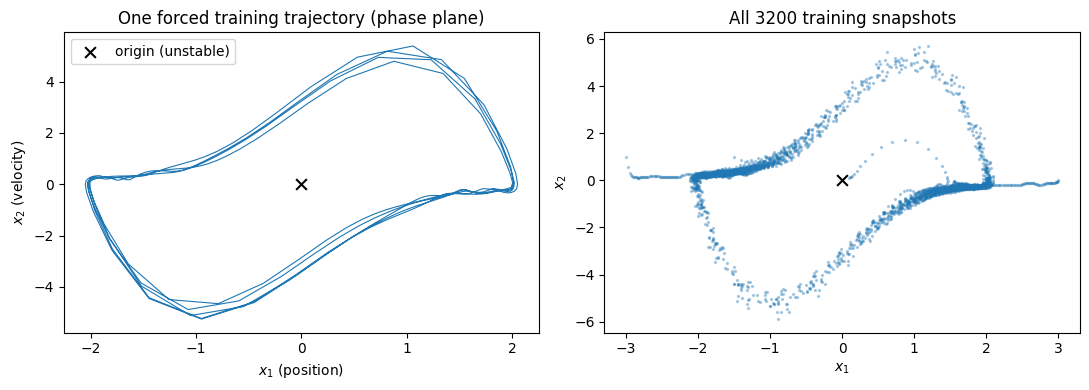

In [4]:
# Visualise one training trajectory and its excitation.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
tr = np.vstack([train_ics[0][None, :], np.asarray(rollout(
    jnp.asarray(train_ics[0]),
    multisine(jnp.asarray(t_grid),
              jax.random.uniform(jax.random.fold_in(key, 0), (N_COMP,), minval=0.05, maxval=1.0),
              jax.random.uniform(jax.random.fold_in(jax.random.fold_in(key, 0), 1), (N_COMP,), minval=0, maxval=2*np.pi),
              TRAIN_AMP), DT))])
ax1.plot(tr[:, 0], tr[:, 1], lw=0.8)
ax1.scatter([0], [0], c='k', marker='x', s=60, label='origin (unstable)')
ax1.set_xlabel(r'$x_1$ (position)'); ax1.set_ylabel(r'$x_2$ (velocity)')
ax1.set_title('One forced training trajectory (phase plane)'); ax1.legend()
allX = X[0]; allY = X[1]
ax2.scatter(allX, allY, s=2, alpha=0.3)
ax2.scatter([0], [0], c='k', marker='x', s=60)
ax2.set_xlabel(r'$x_1$'); ax2.set_ylabel(r'$x_2$')
ax2.set_title(f'All {X.shape[1]} training snapshots')
fig.tight_layout(); plt.show()

*Figure 1: (left) a single forced trajectory wandering under the multisine
input; (right) the cloud of all snapshots. The data covers the interior and the
$\sim\!2$-amplitude limit-cycle region — the excitation is persistently
exciting, so the fit sees the plant everywhere it will operate.*

## 5. DMDc: a linear model in the physical state

We fit Eq. (2) with a single call. `rank=2` keeps the full 2-D state (no POD
truncation needed here).

In [5]:
dmdc_model = dmdc(X, Xp, U, rank=2)
A, B = dmdc_model.A, dmdc_model.B
print("DMDc A =\n", np.round(A, 4))
print("DMDc B =", np.round(B.ravel(), 4))

# The eigenvalues of A tell us what the model *believes* about the origin.
disc_eig = np.linalg.eigvals(A)
cont_eig = np.log(disc_eig.astype(complex)) / DT
print("\nDMDc continuous-time eigenvalues:", np.round(cont_eig, 3))
print("Re(lambda) < 0 for all modes:", bool(np.all(cont_eig.real < 0)))

DMDc A =
 [[ 0.9956  0.0983]
 [-0.087   0.9519]]
DMDc B = [0.0033 0.0669]

DMDc continuous-time eigenvalues: [-0.223+0.92j -0.223-0.92j]
Re(lambda) < 0 for all modes: True


> **Pitfall (the crux of the whole notebook).** The DMDc model's eigenvalues
> have **negative** real part — the best-fit linear model believes the origin is
> a *stable spiral* that trajectories decay into. But the true origin is
> **unstable**; the plant spirals out to a limit cycle. A single global linear
> model cannot be simultaneously unstable near the origin and bounded far away,
> so least-squares splits the difference and picks a *stable* fit. This one
> structural error will sink both the DMDc prediction and the DMDc controller.

### The fitted operator as a simulatable block

`DMDForecaster` wraps $(\mathbf{A}, \mathbf{B})$ as a jax-traceable discrete-time
block that runs *inside* `jaxonomy.simulate`. We drive it with the same input as
the true plant and compare, open-loop, on a fresh validation trajectory.

In [6]:
# A fixed validation input (modest amplitude) and initial condition.
VAL_AMP = 1.0
val_freqs = jax.random.uniform(jax.random.PRNGKey(101), (N_COMP,), minval=0.05, maxval=1.0)
val_phases = jax.random.uniform(jax.random.PRNGKey(102), (N_COMP,), minval=0, maxval=2*np.pi)
def u_val(t):
    return multisine(t, val_freqs, val_phases, VAL_AMP)

x_val0 = np.array([0.5, 0.5])
T_VAL = 6.0
n_val = int(T_VAL / DT)
uv = np.array([float(u_val(k * DT)) for k in range(n_val)])
x_true = np.vstack([x_val0[None, :],
                    np.asarray(rollout(jnp.asarray(x_val0), jnp.asarray(uv), DT))])

def open_loop_predict(block):
    '''Simulate a fitted forecaster block driven by u_val(t).'''
    src = SourceBlock(lambda t, **kw: u_val(t), name="u")
    builder = jaxonomy.DiagramBuilder()
    builder.add(block); builder.add(src)
    builder.connect(src.output_ports[0], block.input_ports[0])   # u -> block
    diagram = builder.build()
    sol = jaxonomy.simulate(
        diagram, diagram.create_context(), (0.0, T_VAL),
        options=SimulatorOptions(max_major_step_size=DT, max_minor_step_size=DT,
                                 buffer_length=4096),
        recorded_signals={"y": block.output_ports[0]})
    return np.asarray(sol.outputs["y"])

dmdc_block = DMDForecaster(A=A, B=B, dt=DT, initial_state=x_val0, name="dmdc")
y_dmdc = open_loop_predict(dmdc_block)
m = min(len(x_true), len(y_dmdc))
rmse_dmdc = np.sqrt(np.mean((y_dmdc[:m] - x_true[:m])**2))
print(f"DMDc open-loop RMSE over {T_VAL}s: {rmse_dmdc:.3f}")
print(f"predicted |x| at t={T_VAL}s: {np.linalg.norm(y_dmdc[-1]):.2f}   "
      f"true |x|: {np.linalg.norm(x_true[-1]):.2f}")

06:58:13.088 - [jaxonomy][INFO]: max_major_steps=118 based on smallest discrete period=0.1


06:58:13.089 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=118, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


DMDc open-loop RMSE over 6.0s: 1.083
predicted |x| at t=6.0s: 0.41   true |x|: 1.47


## 6. Koopman eDMDc: a linear model in a lifted space

Now the lifted model, Eq. (3). We lift with a degree-3 monomial dictionary —
rich enough to contain the $x_1^2 x_2$ term the Van der Pol field needs. Fitting
is again one call; passing `U=U` gives the controlled (eDMDc) variant.

In [7]:
dictionary = polynomial_dictionary(degree=3)
koop_model = edmd(X, Xp, dictionary, U=U)
K, Bz, C = koop_model.K, koop_model.B, koop_model.C
L = K.shape[0]
print(f"Lifted dimension L = {L}   (identity x1,x2 + constant + degree 2-3 monomials)")
print("De-lift C (first two rows) =\n", np.round(C[:2], 3))
print("-> C is exactly [I | 0]: the physical state is read straight off the lift.")

Lifted dimension L = 10   (identity x1,x2 + constant + degree 2-3 monomials)
De-lift C (first two rows) =
 [[ 1. -0. -0. -0. -0.  0. -0. -0.  0.  0.]
 [ 0.  1. -0. -0.  0. -0. -0.  0. -0. -0.]]
-> C is exactly [I | 0]: the physical state is read straight off the lift.


The de-lift matrix $\mathbf{C}$ is exactly $[\mathbf{I}\;|\;\mathbf{0}]$ —
because the identity observables sit first in the dictionary, recovering
$\mathbf{x}$ from $\mathbf{z}$ is just a row selection.

In [8]:
# One-step accuracy on the training data — the metric an MPC actually relies on.
def lift_cols(M):
    return np.column_stack([np.asarray(dictionary(jnp.asarray(M[:, k])))
                            for k in range(M.shape[1])])
Z1, Z2 = lift_cols(X), lift_cols(Xp)
onestep_dmdc = np.sqrt(np.mean((A @ X + B @ U - Xp)**2))
onestep_koop = np.sqrt(np.mean((C @ (K @ Z1 + Bz @ U) - Xp)**2))
print(f"One-step prediction RMSE (physical state):")
print(f"   DMDc    : {onestep_dmdc:.4f}")
print(f"   Koopman : {onestep_koop:.4f}")
print(f"   Koopman is {onestep_dmdc / onestep_koop:.1f}x more accurate per step.")

One-step prediction RMSE (physical state):
   DMDc    : 0.3062
   Koopman : 0.0257
   Koopman is 11.9x more accurate per step.


**The headline number.** Koopman's one-step prediction is roughly an order
of magnitude more accurate than DMDc's. This is precisely the quantity a
receding-horizon controller leans on: an MPC re-measures the state and re-plans
every step, so *one-step model fidelity* dominates closed-loop performance.

### Koopman open-loop prediction vs DMDc vs truth

`KoopmanPredictor` lifts the stored state, advances the lifted linear dynamics,
and de-lifts — all jax-traceable. We overlay both surrogates against the true
trajectory.

06:58:29.910 - [jaxonomy][INFO]: max_major_steps=118 based on smallest discrete period=0.1


06:58:29.911 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=118, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


6.0s free-rollout RMSE:  DMDc 1.083   Koopman 1.423
(Aggregate long-horizon RMSE is a poor metric here: DMDc scores 'well' by
 quietly decaying to the origin, where squared error is small, while the
 Koopman rollout keeps oscillating and drifts in phase. The metric that
 matters for MPC is the one-step error above, and the qualitative plot below.)


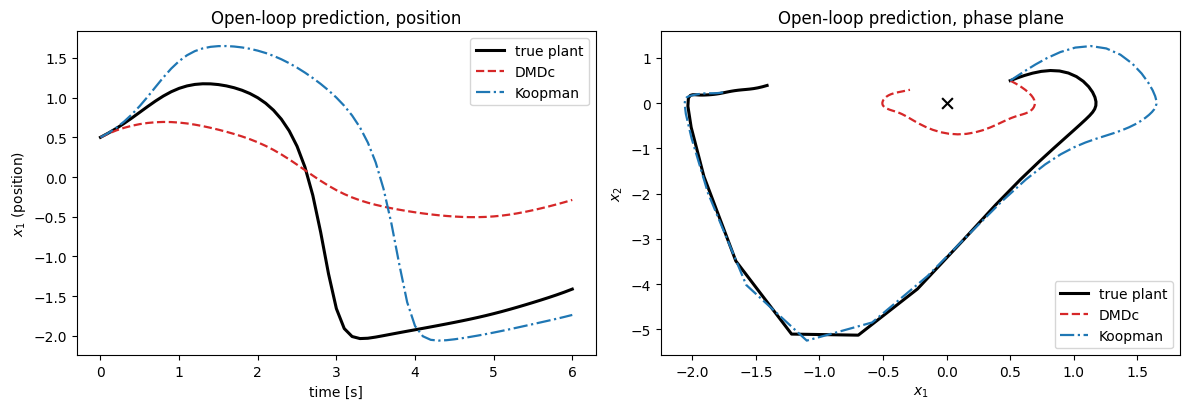

In [9]:
koop_block = KoopmanPredictor(K=K, C=C, dictionary=dictionary, B=Bz,
                              dt=DT, initial_state=x_val0, name="koop")
y_koop = open_loop_predict(koop_block)
m = min(len(x_true), len(y_koop))
rmse_koop = np.sqrt(np.mean((y_koop[:m] - x_true[:m])**2))
print(f"{T_VAL}s free-rollout RMSE:  DMDc {rmse_dmdc:.3f}   Koopman {rmse_koop:.3f}")
print("(Aggregate long-horizon RMSE is a poor metric here: DMDc scores 'well' by")
print(" quietly decaying to the origin, where squared error is small, while the")
print(" Koopman rollout keeps oscillating and drifts in phase. The metric that")
print(" matters for MPC is the one-step error above, and the qualitative plot below.)")

tt = np.arange(m) * DT
fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
axs[0].plot(tt, x_true[:m, 0], 'k', lw=2.2, label='true plant')
axs[0].plot(tt, y_dmdc[:m, 0], 'C3--', lw=1.6, label='DMDc')
axs[0].plot(tt, y_koop[:m, 0], 'C0-.', lw=1.6, label='Koopman')
axs[0].set_xlabel('time [s]'); axs[0].set_ylabel(r'$x_1$ (position)')
axs[0].set_title('Open-loop prediction, position'); axs[0].legend()
axs[1].plot(x_true[:m, 0], x_true[:m, 1], 'k', lw=2.2, label='true plant')
axs[1].plot(y_dmdc[:m, 0], y_dmdc[:m, 1], 'C3--', lw=1.6, label='DMDc')
axs[1].plot(y_koop[:m, 0], y_koop[:m, 1], 'C0-.', lw=1.6, label='Koopman')
axs[1].scatter([0], [0], c='k', marker='x', s=60)
axs[1].set_xlabel(r'$x_1$'); axs[1].set_ylabel(r'$x_2$')
axs[1].set_title('Open-loop prediction, phase plane'); axs[1].legend()
fig.tight_layout(); plt.show()

*Figure 2: open-loop prediction under the validation input. The DMDc
prediction (red dashed) **decays toward the origin** — the visible fingerprint
of its stable-spiral eigenvalues — while the true plant (black) and the Koopman
model (blue) keep oscillating on the limit cycle. Note the subtlety: over a full
6 s the aggregate RMSE can even favour DMDc, because a model that quietly (and
wrongly) settles at the origin accrues less squared error than one that
oscillates slightly out of phase. This is why aggregate rollout RMSE is the
wrong yardstick here. The right ones — the **one-step error** (≈12× better for
Koopman) and the **qualitative** stability of the origin — both indict DMDc: it
gets the stability of the origin wrong, exactly the error a stabilising
controller cannot tolerate.*

## 7. Closing the loop on the true nonlinear plant

Now the real test. We build the true nonlinear plant as a Jaxonomy block with
`ode_block` (a decorator that turns a right-hand side into a `LeafSystem` with a
continuous state and an input port), and control it with a linear MPC built on
each surrogate. The controller only ever sees the *linear* surrogate; the plant
it drives is the *true* Eq. (1).

In [10]:
def build_true_plant():
    '''The true nonlinear Van der Pol plant as a Jaxonomy block.
    Parameters: mu (in vdp_rhs).  State: (x1, x2) continuous.
    Input port 0: control u.  Output port 0: the state.'''
    @ode_block(state_dim=2, num_inputs=1, name="vdp")
    def plant(time, state, u, **params):
        x = state.continuous_state
        return vdp_rhs(x, jnp.atleast_1d(u)[0])
    return plant

def set_plant_ic(diagram, plant, x0):
    ctx = diagram.create_context()
    return ctx.with_subcontext(
        plant.system_id, ctx[plant.system_id].with_continuous_state(jnp.asarray(x0)))

# Fixed-step RK4 in closed loop: the control is a zero-order hold at DT, so a
# fixed step matches how the data was generated and keeps the solver honest.
def sim_options():
    return SimulatorOptions(ode_solver_method="rk4", max_major_step_size=DT,
                            max_minor_step_size=DT, buffer_length=4096)

X0 = np.array([2.0, 0.0])   # start on the limit cycle; goal: drive to the origin
T_CTRL = 10.0

### 7a. A ready-made linear MPC on the DMDc model

Jaxonomy ships `LinearDiscreteTimeMPC`, an OSQP-backed linear MPC. It expects a
*continuous-time* `LTISystem` and Euler-discretises it internally as
$\mathbf{A}_d = \mathbf{I} + \Delta t\,\mathbf{A}_c$, $\mathbf{B}_d = \Delta t\,
\mathbf{B}_c$. Our DMDc operators are already *discrete*, so we hand it the
"un-discretised" continuous equivalents $\mathbf{A}_c = (\mathbf{A}-\mathbf{I})/
\Delta t$, $\mathbf{B}_c = \mathbf{B}/\Delta t$; the block's Euler step then
reconstructs our exact discrete model. We give the controller generous authority
($|u|\le 4$) for this first demonstration.

In [11]:
Q = np.eye(2); R = np.array([[0.1]]); N_HORIZON = 20

A_c = (A - np.eye(2)) / DT      # un-discretise so the block's Euler step -> (A, B)
B_c = B / DT
dmdc_lti = LTISystem(A_c, B_c, np.eye(2), np.zeros((2, 1)))

plant = build_true_plant()
lib_mpc = LinearDiscreteTimeMPC(dmdc_lti, Q, R, N_HORIZON, DT, x_ref=np.zeros(2),
                                lbu=-4.0, ubu=4.0, name="dmdc_mpc")
builder = jaxonomy.DiagramBuilder()
builder.add(plant); builder.add(lib_mpc)
builder.connect(plant.output_ports[0], lib_mpc.input_ports[0])   # x -> mpc
builder.connect(lib_mpc.output_ports[0], plant.input_ports[0])   # u -> plant
diagram = builder.build()
sol = jaxonomy.simulate(diagram, set_plant_ic(diagram, plant, X0), (0.0, T_CTRL),
                        options=sim_options(),
                        recorded_signals={"x": plant.output_ports[0],
                                          "u": lib_mpc.output_ports[0]})
t_lib = np.asarray(sol.time)
x_lib = np.asarray(sol.outputs["x"]); u_lib = np.asarray(sol.outputs["u"])
late = int(3.0 / DT)
print(f"Library DMDc-MPC, |u|<=4: residual RMS over last 3s = "
      f"{np.sqrt(np.mean(np.linalg.norm(x_lib[-late:], axis=1)**2)):.3f}")

06:58:30.973 - [jaxonomy][INFO]: max_major_steps=198 based on smallest discrete period=0.1


06:58:30.973 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=198, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), RK4Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Library DMDc-MPC, |u|<=4: residual RMS over last 3s = 0.244


With generous authority the ready-made MPC suppresses most of the limit
cycle but — because its model is structurally wrong about the origin — leaves a
residual it cannot remove by force alone. This already hints that **the model,
not the controller, is the bottleneck.** Next we make the actuator realistic and
the gap becomes decisive.

### 7b. Why the ready-made MPC cannot take the Koopman model

The natural next step — hand the lifted $(\mathbf{K}, \mathbf{B}_z)$ to the same
block — does not work. `LinearDiscreteTimeMPC` imposes a **hard terminal
equality** $\mathbf{x}_{N-1} = \mathbf{x}_{\text{ref}}$ on its *entire* state
vector. In lifted coordinates that means forcing all $L$ observables (including
$x_1^2, x_1^2 x_2, \dots$) to hit $\mathbf{g}(\mathbf{0})$ exactly — an
over-determined target that is infeasible under bounded input. We can see the QP
report it directly:

In [12]:
K_c = (K - np.eye(L)) / DT
Bz_c = Bz / DT
koop_lti = LTISystem(K_c, Bz_c, np.eye(L), np.zeros((L, 1)))
z_ref = np.asarray(dictionary(jnp.zeros(2)))
Qz = np.zeros((L, L)); Qz[0, 0] = 1.0; Qz[1, 1] = 1.0   # weight physical rows
probe_mpc = LinearDiscreteTimeMPC(koop_lti, Qz, R, N_HORIZON, DT, x_ref=z_ref,
                                  lbu=-4.0, ubu=4.0, name="probe")
z0 = np.asarray(dictionary(jnp.asarray(X0)))
lb, ub = probe_mpc._get_bounds(jnp.asarray(z0))
probe_mpc.solver.update(l=np.array(lb), u=np.array(ub))
status = probe_mpc.solver.solve().info.status
print(f"OSQP status when the lifted model is fed to the terminal-equality MPC: "
      f"'{status}'")

OSQP status when the lifted model is fed to the terminal-equality MPC: 'primal infeasible'


The solver returns **primal infeasible**. The standard Koopman-MPC recipe
(Korda & Mezić 2018) avoids this by using a *terminal cost* rather than a
terminal equality, so the lifted state is guided toward — not pinned to — the
target. We build that controller next and, for a fair head-to-head, run it on
**both** surrogates.

### 7c. A terminal-cost linear MPC (the Korda–Mezić form)

This compact `LeafSystem` condenses the horizon into a dense QP in the input
sequence with a quadratic stage-and-terminal cost and box constraints on $u$.
It optionally lifts its measured input through a dictionary, so the *same* block
serves the DMDc model (identity lift) and the Koopman model (polynomial lift).
The QP is solved by OSQP inside a `jax.pure_callback`, exactly as the library
block does, so it runs inside `jaxonomy.simulate`.

In [13]:
from functools import partial
from scipy import sparse
import osqp
from jaxonomy.framework import LeafSystem
from jaxonomy.backend import cond

class TerminalCostMPC(LeafSystem):
    '''Dense-form linear MPC with terminal cost + input box constraints.

    Model:  z_{k+1} = A z_k + B u_k,  y_k = C z_k,  z = lift(measured x).
    Cost:   sum_k (y_k - r)'Qy(y_k - r) + u_k'R u_k  + terminal (y_N - r)'Qf(y_N - r).
    Parameters: prediction matrices (static).  Input port 0: measured x.
    Output port 0: first optimal input u_0 (zero-order hold at dt).
    '''
    def __init__(self, A, B, C, lift, Qy, R, Qf, N, umax, ref, dt, name=None):
        super().__init__(name=name)
        A, B, C = np.asarray(A), np.asarray(B), np.asarray(C)
        n, m = B.shape; p = C.shape[0]
        self.m = m; self.lift = lift
        Apow = [np.linalg.matrix_power(A, k) for k in range(N + 1)]
        Phi = np.zeros((N * p, n)); Gam = np.zeros((N * p, N * m))
        for k in range(1, N + 1):                    # stack y_1..y_N
            Phi[(k-1)*p:k*p] = C @ Apow[k]
            for j in range(k):
                Gam[(k-1)*p:k*p, j*m:(j+1)*m] = C @ Apow[k-1-j] @ B
        Qbar = np.kron(np.eye(N), Qy); Qbar[(N-1)*p:, (N-1)*p:] = Qf
        Rbar = np.kron(np.eye(N), np.atleast_2d(R))
        H = Gam.T @ Qbar @ Gam + Rbar; H = 0.5 * (H + H.T)
        self._M = Gam.T @ Qbar; self._Phi = Phi; self._ref = np.tile(np.asarray(ref), N)
        self.solver = osqp.OSQP()
        self.solver.setup(P=sparse.csc_matrix(H), q=np.zeros(N * m),
                          A=sparse.csc_matrix(np.eye(N * m)),
                          l=-umax * np.ones(N * m), u=umax * np.ones(N * m),
                          verbose=False, eps_abs=1e-7, eps_rel=1e-7, max_iter=10000)
        self.declare_input_port()
        self._tmpl = jnp.zeros(m)
        self._jax_solve = partial(jax.pure_callback, self._np_solve, self._tmpl)
        self.declare_output_port(self._output, requires_inputs=True, period=dt, offset=0.0)

    def _np_solve(self, time, state, x):            # runs on concrete numpy arrays
        z = np.asarray(self.lift(jnp.asarray(x)))
        f = self._M @ (self._Phi @ z - self._ref)
        self.solver.update(q=np.asarray(f))
        return np.asarray(self.solver.solve().x[:self.m], dtype=float)

    def _dummy(self, *a):
        return jnp.full(self._tmpl.shape, jnp.inf)   # guard for minor ODE steps

    def _output(self, time, state, *inp):
        return cond(jnp.isinf(time), self._dummy, self._jax_solve, time, state, inp[0])

print("TerminalCostMPC defined.")

TerminalCostMPC defined.


In [14]:
# One controller factory, two models. Tight actuator: |u| <= 1.5.
UMAX = 1.5; N_TC = 30
Qy = np.eye(2); R_tc = np.array([[0.01]]); Qf = np.eye(2) * 10.0
identity_lift = lambda x: jnp.atleast_1d(x)

def run_tc_mpc(A_mdl, B_mdl, C_mdl, lift, umax=UMAX, N=N_TC, T=12.0, x0=X0):
    plant = build_true_plant()
    mpc = TerminalCostMPC(A_mdl, B_mdl, C_mdl, lift, Qy, R_tc, Qf, N, umax,
                          ref=np.zeros(2), dt=DT, name="tc_mpc")
    builder = jaxonomy.DiagramBuilder()
    builder.add(plant); builder.add(mpc)
    builder.connect(plant.output_ports[0], mpc.input_ports[0])   # x -> mpc
    builder.connect(mpc.output_ports[0], plant.input_ports[0])   # u -> plant
    diagram = builder.build()
    sol = jaxonomy.simulate(diagram, set_plant_ic(diagram, plant, x0), (0.0, T),
                            options=sim_options(),
                            recorded_signals={"x": plant.output_ports[0],
                                              "u": mpc.output_ports[0]})
    return np.asarray(sol.time), np.asarray(sol.outputs["x"]), np.asarray(sol.outputs["u"])

t_d, x_d, u_d = run_tc_mpc(A,  B,  np.eye(2), identity_lift)   # DMDc model
t_k, x_k, u_k = run_tc_mpc(K,  Bz, C,         dictionary)      # Koopman model

def late_rms(x, secs=3.0):
    w = int(secs / DT); return np.sqrt(np.mean(np.linalg.norm(x[-w:], axis=1)**2))
print(f"Closed loop on the TRUE plant, |u| <= {UMAX}:")
print(f"   DMDc-MPC    residual RMS (last 3s): {late_rms(x_d):.3f}")
print(f"   Koopman-MPC residual RMS (last 3s): {late_rms(x_k):.3f}")

06:58:31.817 - [jaxonomy][INFO]: max_major_steps=238 based on smallest discrete period=0.1


06:58:31.817 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=238, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), RK4Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


06:58:32.067 - [jaxonomy][INFO]: max_major_steps=238 based on smallest discrete period=0.1


06:58:32.068 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=238, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), RK4Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Closed loop on the TRUE plant, |u| <= 1.5:
   DMDc-MPC    residual RMS (last 3s): 2.028
   Koopman-MPC residual RMS (last 3s): 0.035


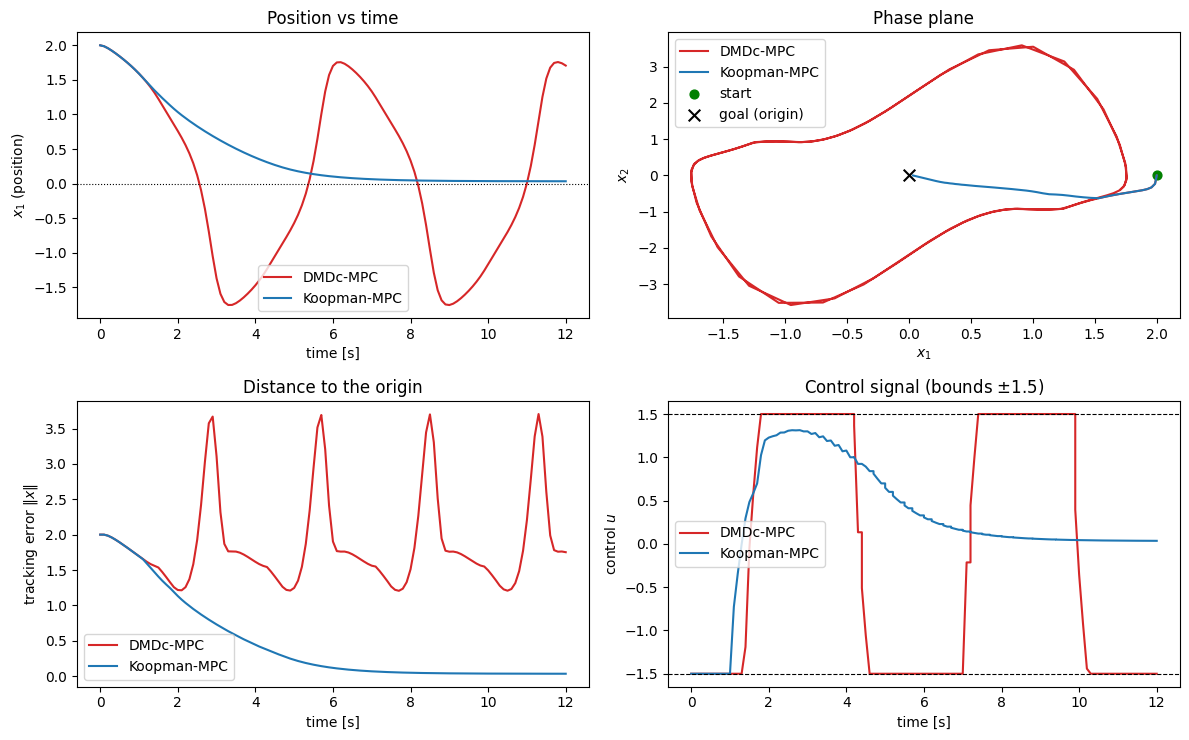

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7.5))
axs[0,0].plot(t_d, x_d[:, 0], 'C3', label='DMDc-MPC')
axs[0,0].plot(t_k, x_k[:, 0], 'C0', label='Koopman-MPC')
axs[0,0].axhline(0, color='k', lw=0.8, ls=':')
axs[0,0].set_xlabel('time [s]'); axs[0,0].set_ylabel(r'$x_1$ (position)')
axs[0,0].set_title('Position vs time'); axs[0,0].legend()

axs[0,1].plot(x_d[:, 0], x_d[:, 1], 'C3', label='DMDc-MPC')
axs[0,1].plot(x_k[:, 0], x_k[:, 1], 'C0', label='Koopman-MPC')
axs[0,1].scatter([2], [0], c='g', marker='o', s=40, label='start')
axs[0,1].scatter([0], [0], c='k', marker='x', s=70, label='goal (origin)')
axs[0,1].set_xlabel(r'$x_1$'); axs[0,1].set_ylabel(r'$x_2$')
axs[0,1].set_title('Phase plane'); axs[0,1].legend()

err_d = np.linalg.norm(x_d, axis=1); err_k = np.linalg.norm(x_k, axis=1)
axs[1,0].plot(t_d, err_d, 'C3', label='DMDc-MPC')
axs[1,0].plot(t_k, err_k, 'C0', label='Koopman-MPC')
axs[1,0].set_xlabel('time [s]'); axs[1,0].set_ylabel(r'tracking error $\|x\|$')
axs[1,0].set_title('Distance to the origin'); axs[1,0].legend()

axs[1,1].plot(t_d[:len(u_d)], u_d, 'C3', label='DMDc-MPC')
axs[1,1].plot(t_k[:len(u_k)], u_k, 'C0', label='Koopman-MPC')
axs[1,1].axhline(UMAX, color='k', lw=0.8, ls='--'); axs[1,1].axhline(-UMAX, color='k', lw=0.8, ls='--')
axs[1,1].set_xlabel('time [s]'); axs[1,1].set_ylabel('control $u$')
axs[1,1].set_title(f'Control signal (bounds $\\pm{UMAX}$)'); axs[1,1].legend()
fig.tight_layout(); plt.show()

*Figure 3: closed-loop stabilisation of the true nonlinear plant from the
limit cycle, same controller formulation, tight actuator $|u|\le1.5$. The
**Koopman-MPC (blue) drives the plant to the origin**; the **DMDc-MPC (red)
fails** — it cannot overcome the negative damping its model does not know about,
and settles into a residual limit cycle. The distance-to-origin panel makes the
verdict quantitative: Koopman collapses toward zero, DMDc plateaus near the
limit-cycle amplitude.*

### Actuator diagnostics

The tutorial-author discipline requires running `analyze_saturation` on every
actuator. With a deliberately tight bound both controllers press the limits
while working — that is *by design* here (we chose $u_{\max}$ small to expose the
model-quality gap), not a tuning bug.

In [16]:
rep_d = analyze_saturation(u_d, lower=-UMAX, upper=UMAX, name="u (DMDc-MPC)", warn=False)
rep_k = analyze_saturation(u_k, lower=-UMAX, upper=UMAX, name="u (Koopman-MPC)", warn=False)
print(f"DMDc-MPC    control saturated {rep_d.fraction_saturated*100:.0f}% of the time")
print(f"Koopman-MPC control saturated {rep_k.fraction_saturated*100:.0f}% of the time")
print("\nInterpretation: the DMDc-MPC saturates chronically because it is fighting a"
      "\nlimit cycle it cannot model; the Koopman-MPC uses brief bursts to stabilise,"
      "\nthen relaxes. Saturation here is expected given the small u_max, not a bug.")

DMDc-MPC    control saturated 88% of the time
Koopman-MPC control saturated 8% of the time

Interpretation: the DMDc-MPC saturates chronically because it is fighting a
limit cycle it cannot model; the Koopman-MPC uses brief bursts to stabilise,
then relaxes. Saturation here is expected given the small u_max, not a bug.


### 7d. Is the win robust? A sweep over actuator authority

A single operating point could be a lucky knob setting. We sweep the actuator
bound $u_{\max}$ and re-run both controllers. Each closed-loop solve is a small
QP, so the whole sweep is cheap.

06:58:32.565 - [jaxonomy][INFO]: max_major_steps=238 based on smallest discrete period=0.1


06:58:32.566 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=238, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), RK4Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


06:58:32.726 - [jaxonomy][INFO]: max_major_steps=238 based on smallest discrete period=0.1


06:58:32.726 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=238, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), RK4Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


06:58:33.045 - [jaxonomy][INFO]: max_major_steps=238 based on smallest discrete period=0.1


...

06:58:34.629 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=238, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), RK4Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


06:58:34.944 - [jaxonomy][INFO]: max_major_steps=238 based on smallest discrete period=0.1


06:58:34.945 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=238, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), RK4Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


06:58:35.101 - [jaxonomy][INFO]: max_major_steps=238 based on smallest discrete period=0.1


06:58:35.101 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.1, max_major_steps=238, ode_solver_method=rk4, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=0.1, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), RK4Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=0.1, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


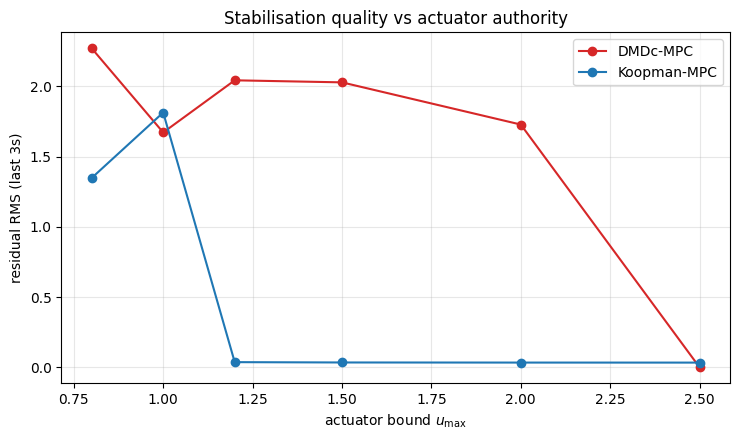

Koopman residual RMS: ['1.35', '1.81', '0.04', '0.03', '0.03', '0.03']
DMDc    residual RMS: ['2.27', '1.67', '2.04', '2.03', '1.73', '0.00']


In [17]:
umax_grid = [0.8, 1.0, 1.2, 1.5, 2.0, 2.5]
rms_d, rms_k = [], []
for um in umax_grid:
    _, xd_s, _ = run_tc_mpc(A,  B,  np.eye(2), identity_lift, umax=um, T=12.0)
    _, xk_s, _ = run_tc_mpc(K,  Bz, C,         dictionary,   umax=um, T=12.0)
    rms_d.append(late_rms(xd_s)); rms_k.append(late_rms(xk_s))

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(umax_grid, rms_d, 'C3-o', label='DMDc-MPC')
ax.plot(umax_grid, rms_k, 'C0-o', label='Koopman-MPC')
ax.set_xlabel(r'actuator bound $u_{\max}$'); ax.set_ylabel('residual RMS (last 3s)')
ax.set_title('Stabilisation quality vs actuator authority'); ax.legend()
ax.grid(alpha=0.3); fig.tight_layout(); plt.show()
print("Koopman residual RMS:", [f"{v:.2f}" for v in rms_k])
print("DMDc    residual RMS:", [f"{v:.2f}" for v in rms_d])

*Figure 4: the Koopman-MPC (blue) stabilises the plant across a broad band
of actuator authority ($u_{\max}\gtrsim1.2$, residual $\approx0$), while the
DMDc-MPC (red) leaves a large residual until it is given enough brute-force
authority to overpower the plant. The advantage is a wide plateau, not a
knife-edge — the Koopman model is *structurally* better, not just better-tuned.*

## 8. Failure modes — when this breaks

- **Dictionary too small.** A degree-1 (identity) dictionary reduces eDMDc to
  plain DMDc and the win vanishes; a degree-2 dictionary lacks the $x_1^2 x_2$
  term the Van der Pol field needs and only partially helps. Too *large* a
  dictionary overfits and worsens extrapolation. Degree 3 is the sweet spot here
  — Exercise 1 makes you find it.
- **Weak excitation.** If the training input is not persistently exciting (too
  low amplitude, too few frequencies, or only near the limit cycle), $\mathbf{B}$
  and the interior dynamics are poorly identified, and *both* models degrade. The
  snapshots must visit the region the controller will drive through.
- **Extrapolation / distribution shift.** A Koopman model is only trustworthy
  where it saw data. Under aggressive control the state can leave the training
  region; the lifted monomials then extrapolate super-linearly and predictions
  can blow up. Keeping the closed-loop trajectory inside the sampled region (or
  sampling more widely) matters.
- **Authority mismatch.** With *very* generous authority even a wrong model can
  brute-force stabilisation (Figure 4, right side), hiding the model-quality gap;
  with *too little* authority nothing stabilises. The interesting — and
  realistic — regime is in between.


## 9. Exercises

1. **(Dictionary sweep — code.)** Re-fit the Koopman model with
   `polynomial_dictionary(degree=d)` for `d in [1, 2, 3, 4, 5]`. Plot the
   one-step training RMSE and the closed-loop residual RMS versus `d`. Where does
   the benefit saturate, and where does overfitting begin to hurt?

2. **(Excitation — code.)** Halve `TRAIN_AMP` and drop `N_COMP` to 2, then
   re-identify both models and re-run the closed loop. How much does the
   Koopman advantage shrink when the data is less persistently exciting? Explain
   which operator ($\mathbf{K}$ or $\mathbf{B}_z$) you expect to suffer most.

3. **(Reasoning.)** The DMDc model has stable eigenvalues yet the true origin is
   unstable. Explain, in terms of the least-squares objective and the geometry of
   the limit cycle, why a *single* global linear model is forced to pick a stable
   fit. What would change if you fit DMDc using **only** snapshots from a small
   ball around the origin?

4. **(Open-ended.)** Replace the monomial dictionary with a
   `rbf_dictionary(centers, epsilon)` whose centres you place on a grid over the
   sampled state region. Can you match or beat the degree-3 monomial model with
   fewer lifted dimensions? Then try *setpoint tracking* to a non-zero reference
   $x_1^\star \neq 0$ (a Van der Pol equilibrium requires steady $u = x_1^\star$)
   and compare DMDc vs Koopman there. Where does each formulation shine?


## 10. Key takeaways

- **A linear surrogate lets you keep a fast, convex linear MPC on a nonlinear
  plant** — if the surrogate is faithful where it matters (one step ahead).
- **DMDc fits one global linear model in the physical state.** On a plant with an
  unstable origin and a limit cycle it is forced into a qualitatively wrong
  (stable) fit, and its MPC cannot stabilise under realistic actuator limits.
- **Koopman eDMDc fits a linear model in a lifted space.** The extra observables
  give the linear operator room to capture the nonlinearity: ≈12× better one-step
  prediction here, and a controller that actually works.
- **One-step accuracy predicts closed-loop success.** Because MPC re-plans every
  step, the per-step model error — not the long-horizon rollout error — is the
  quantity to watch.
- **Know your controller's constraints.** `LinearDiscreteTimeMPC`'s hard terminal
  equality suits a physical-state model but is infeasible for a lifted model; the
  Korda–Mezić terminal-cost form is the right tool for Koopman-MPC.

**Next steps.** Explore the rest of `jaxonomy.library.rom` — POD/Galerkin
projection, balanced truncation (`balred`), and statistical surrogates
(`fit_gp`, `fit_pce`). For nonlinear MPC without a linear surrogate, see the
`DirectShootingNMPC` / `HermiteSimpsonNMPC` blocks.


## 11. References

1. J. L. Proctor, S. L. Brunton, J. N. Kutz. *Dynamic Mode Decomposition with
   Control.* SIAM J. Applied Dynamical Systems 15(1), 2016.
2. M. O. Williams, I. G. Kevrekidis, C. W. Rowley. *A Data-Driven Approximation
   of the Koopman Operator: Extending Dynamic Mode Decomposition.* J. Nonlinear
   Science 25(6), 2015.
3. M. Korda, I. Mezić. *Linear predictors for nonlinear dynamical systems:
   Koopman operator meets model predictive control.* Automatica 93, 2018.
4. S. L. Brunton, J. N. Kutz. *Data-Driven Science and Engineering.* Cambridge
   University Press, 2019 (Ch. 7–10).
